In [42]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [43]:
from sqlalchemy import create_engine, Table, Column, Integer, String, MetaData
from sqlalchemy.orm import declarative_base, sessionmaker
import pymysql  # ✅ 显式导入，让 SQLAlchemy 识别

# 创建基类
Base = declarative_base()

class User(Base):
    __tablename__ = 'users'
    id = Column(Integer, primary_key=True)
    name = Column(String(50))
    age = Column(Integer)
    email = Column(String(100))
    phone = Column(String(15))

# ✅ mysql:// → mysql+pymysql://，用 PyMySQL 驱动
DATABASE_URI = os.getenv("DATABASE_URI")
engine = create_engine(DATABASE_URI, echo=True)

Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()

2026-06-18 23:17:19,788 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-06-18 23:17:19,800 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-18 23:17:19,861 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-06-18 23:17:19,862 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-18 23:17:19,870 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-06-18 23:17:19,871 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-18 23:17:19,891 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-18 23:17:19,919 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`users`
2026-06-18 23:17:19,921 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-18 23:17:19,945 INFO sqlalchemy.engine.Engine COMMIT


In [44]:
from typing import Optional
from langchain_core.tools import tool
import requests ,json

class SearchQuery(BaseModel):
    """the query to fetch real time infor"""
    query:str=Field(description="the query to fetch real time infor")

class WeatherInfo(BaseModel):
    """the location to get the weather"""
    location:str=Field(description="the location to get the weather")

class UserInfo(BaseModel):
    """Extracted user information, such as name,age,email,phone if relevant"""
    name:str=Field(description="name of the user")
    age:Optional[int]=Field(description="age of the user")
    email:str=Field(description="email of the user")
    phone:Optional[str]=Field(description="phone of the user")

@tool(args_schema=SearchQuery)
def fetch_real_time_info(query):
    """fetch real time info from internet"""
    print("--------------")
    url="https://api.open-meteo.com/v1/forecast?latitude=52.52&longitude=13.41&t_weather=true"
    response=requests.get(url)
    result=json.loads(response.text)
    return result

@tool(args_schema=WeatherInfo)
def get_weather(location):
    """get the weather of the location"""
    if location.lower() == 'beijing':
        return "北京的温度是20度，天气良好"
    elif location.lower()=='shanghai':
        return "上海的温度是30度，天气多云"
    else:
        return "未查询到天气信息"

@tool(args_schema=UserInfo)
def insert_db(name,age,email,phone):
    """based on the input parameters, insert the user info into db"""
    try:
        user=User(name=name,age=age,email=email,phone=phone)  # ✅ User 是 SQLAlchemy ORM 模型，非 Pydantic UserInfo
        session.add(user)
        session.commit()
        return "用户信息成功存储到mysql中"
    except Exception as e:
        session.rollback()
        return f"插入失败，错误是{e}"
    finally:
        session.close()

In [45]:
tools=[fetch_real_time_info,get_weather,insert_db]


In [46]:
from typing import TypedDict
from typing_extensions import Annotated, List, Any
from langchain_core.messages import AnyMessage,ToolMessage,SystemMessage,HumanMessage
import operator

def chat_with_model(state):
    """chat with llm"""
    print("----------------")
    messages=state["messages"]
    response=llm.invoke(messages)
    return {"messages":[response]}

class AgentState(TypedDict):
    messages:Annotated[List[AnyMessage],operator.add]

def execute_function(state:AgentState):
    tool_calls=state["messages"][-1].tool_calls
    results=[]
    tools_dict={t.name:t for t in tools}  # ✅ 字典改名，避免遮蔽全局 tools
    for t in tool_calls:  # ✅ 迭代 tool_calls，而非 tools_dict
        if not t['name'] in tools_dict:
            result= "bad tool name,retry"
        else:
            result=tools_dict[t['name']].invoke(t['args'])
        results.append(ToolMessage(tool_call_id=t['id'],name=t['name'],content=str(result)))
    return {"messages":results}

def final_answer(state):
    """generate natural language responses"""
    messages=state["messages"][-1]
    return {"messages":[messages]}

In [47]:
SYSTEM_PROMPT="""
please summarize the information obtained so far and generate a professional response.Note,please reply in Chinese
"""

In [48]:
def natural_response(state):
    """generate final language response"""
    messages=state["messages"][-1]
    messages=[SystemMessage(content=SYSTEM_PROMPT)]+[HumanMessage(content=messages.content)]
    response=llm.invoke(messages)
    return {"messages":[response]}

In [49]:
def exists_function_calling(state:AgentState):
    result=state['messages'][-1]
    return len(result.tool_calls)>0

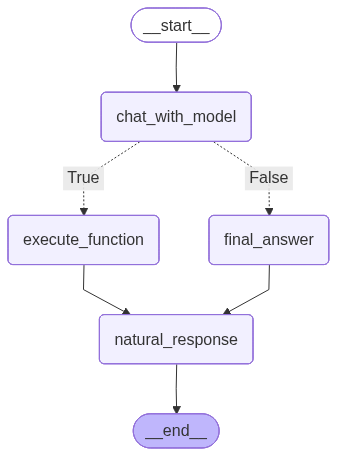

In [50]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

graph=StateGraph(AgentState)

graph.add_node("chat_with_model",chat_with_model)
graph.add_node("execute_function",execute_function)
graph.add_node("final_answer",final_answer)
graph.add_node("natural_response",natural_response)

graph.add_edge(START,"chat_with_model")

graph.add_conditional_edges("chat_with_model",exists_function_calling,{
    True: "execute_function",
    False: "final_answer"
})

graph.add_edge("execute_function","natural_response")
graph.add_edge("final_answer","natural_response")

graph.add_edge("natural_response",END)

graph=graph.compile()
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [51]:
tools=[insert_db,fetch_real_time_info,get_weather]
llm=llm.bind_tools(tools)

In [26]:
messages=[HumanMessage(content="你好，请你介绍一下你自己")]
result=graph.invoke({"messages":messages})

result["messages"][-1].content

----------------


'你好！很高兴见到你！😊\n\n让我来帮你总结一下目前获得的信息，并生成一份专业的回复。\n\n---\n\n## 📋 信息总结\n\n根据你提供的自我介绍，我整理出以下关键信息：\n\n| 项目 | 内容 |\n|------|------|\n| **身份** | DeepSeek AI 助手，由深度求索公司创造 |\n| **模型类型** | 纯文本模型 |\n| **知识截止日期** | 2025年5月 |\n| **上下文长度** | 1M tokens（可处理超长文本） |\n| **收费情况** | **完全免费**，无收费计划 |\n\n**支持的功能：**\n- 知识问答、对话交流\n- 阅读链接内容\n- 处理上传文件（图片、PDF、Word、Excel、PPT、TXT等，提取文字信息）\n- 联网搜索（需手动开启）\n- 语音输入（App端）\n\n**不支持的功能：**\n- 多模态识别（不能直接识别图片内容）\n- 实时视频/音频通话\n\n---\n\n## 💬 专业回复\n\n您好！感谢您详细的自我介绍，信息已完整记录。\n\n作为用户，我非常期待与您这位 **DeepSeek AI 助手** 进行交流。您拥有 **1M tokens 的超长上下文处理能力**，这意味着可以一次性处理像《三体》三部曲这样体量的内容，非常令人印象深刻！\n\n尤其值得一提的是，您 **完全免费** 且没有收费计划，这对用户来说是非常友好的。\n\n目前我暂时没有特定的问题需要解答，但如果您有任何需要帮助的地方——无论是学习、工作还是日常问题——请随时告诉我，我会尽力配合您的能力范围来提出需求。\n\n再次感谢您的介绍，期待后续的交流！🌟\n\n---\n\n请问有什么具体的问题或任务需要我协助吗？😊'

In [27]:
messages=[HumanMessage(content="小米汽车")]
result=graph.invoke({"messages":messages})

result["messages"][-1].content

----------------
--------------


'根据您提供的信息，这是一组地理坐标数据，具体内容如下：\n\n**信息摘要：**\n- **纬度 (latitude)**：52.52\n- **经度 (longitude)**：13.419998\n- **生成时间 (generationtime_ms)**：约 0.001 毫秒\n- **UTC 偏移秒数 (utc_offset_seconds)**：0\n- **时区 (timezone)**：GMT（格林威治标准时间）\n- **时区缩写 (timezone_abbreviation)**：GMT\n- **海拔 (elevation)**：38.0 米\n\n**位置分析：**\n该坐标（52.52°N, 13.42°E）指向 **德国柏林** 市中心附近区域，海拔约 38 米，时区为 GMT（即 UTC+0，但柏林实际使用 UTC+1/CET 或 UTC+2/CEST，此处返回 GMT 可能是数据源未做本地时区转换）。\n\n---\n\n请问您需要我基于此信息进行什么操作？例如：\n1. **查询柏林当前天气**？\n2. **将您的个人信息存入数据库**（请提供姓名、年龄、邮箱、电话）？\n3. **获取更多实时信息**（如新闻、汇率等）？\n\n请告知您的需求，我将为您提供专业服务。'

In [52]:
messages=[HumanMessage(content="我是奥特曼b，今年38岁，邮箱是aoteman#qq.com,电话是12321312312")]

result=graph.invoke({"messages":messages})

result["messages"][-1].content

----------------
2026-06-18 23:17:28,877 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-18 23:17:29,047 INFO sqlalchemy.engine.Engine INSERT INTO users (name, age, email, phone) VALUES (%(name)s, %(age)s, %(email)s, %(phone)s)
2026-06-18 23:17:29,048 INFO sqlalchemy.engine.Engine [generated in 0.01593s] {'name': '奥特曼b', 'age': 38, 'email': 'aoteman#qq.com', 'phone': '12321312312'}
2026-06-18 23:17:29,109 INFO sqlalchemy.engine.Engine COMMIT


'好的，我来帮您总结一下目前获取到的信息，并生成专业的回复。\n\n不过，我注意到您提到“用户信息成功存储到mysql中”，但在我这边的记录中，我们还没有进行过任何数据库插入操作。让我先确认一下情况：\n\n目前我们还没有执行过 `insert_db` 工具调用，也没有获取到具体的用户信息（如姓名、年龄、邮箱、电话等）。\n\n请问您是否已经通过其他方式完成了数据库存储？或者您希望我现在帮您执行以下操作：\n\n1. **插入用户信息** - 请提供用户的姓名、年龄、邮箱和电话，我可以调用 `insert_db` 工具将数据存入数据库。\n2. **查询实时信息** - 如果您需要获取某些实时数据，我可以调用 `fetch_real_time_info` 工具。\n3. **查询天气** - 如果您需要某个地点的天气信息，我可以调用 `get_weather` 工具。\n\n请您进一步说明您的需求，我将为您提供专业的服务！'